# pybalmorel for Post-Processing
This notebook provide examples on how to use pybalmorel for pre-processing, post-processing and for executing Balmorel scenarios. Check the following pages:
- [Home](../README.md)
- [Pre-Processing](PreProcessing.ipynb)
- [Execution](Execution.ipynb)

In [13]:
import os
import pandas as pd
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# Adjust the sys.path to include the project root directory
project_root = os.path.abspath(os.path.join(os.path.dirname("__file__"), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from src.pybalmorel import MainResults

gams_system_directory = "/Library/Frameworks/GAMS.framework/Versions/53/Resources"

In [14]:
import pandas as pd


def create_balmorel_datetime_df(
    year: int,
    n_seasons: int = 52,
    time_col: str = "TTT",
    season_col: str = "SSS",
):
    """
    Create a datetime dataframe following a simple Balmorel SSS-TTT logic.

    The year is divided into n_seasons blocks.
    Each timestamp receives:
        - SSS: season identifier
        - TTT: time-step identifier within the season
        - DATETIME: real datetime
        - Year, Month, Day, Hour
    """

    # Full hourly datetime range for the selected year
    datetime_index = pd.date_range(
        start=f"{year}-01-01 00:00:00",
        end=f"{year}-12-31 23:00:00",
        freq="h",
    )

    df_time = pd.DataFrame({"DATETIME": datetime_index})

    df_time["Year"] = df_time["DATETIME"].dt.year
    df_time["Month"] = df_time["DATETIME"].dt.month
    df_time["Day"] = df_time["DATETIME"].dt.day
    df_time["Hour"] = df_time["DATETIME"].dt.hour + 1

    # Sequential hour of the year: 1 to 8760 or 8784
    df_time["HourOfYear"] = range(1, len(df_time) + 1)

    # Assign seasons as evenly as possible across the year
    df_time[season_col] = (
        ((df_time["HourOfYear"] - 1) * n_seasons // len(df_time)) + 1
    )

    # Time step inside each SSS block
    df_time[time_col] = (
        df_time
        .groupby(season_col)
        .cumcount()
        + 1
    )

    # Balmorel-like string labels
    df_time[season_col] = "S" + df_time[season_col].astype(str).str.zfill(2)
    df_time[time_col] = "T" + df_time[time_col].astype(str).str.zfill(3)

    return df_time

In [15]:
### 1.1.2 Loading several scenarios
res = MainResults(files=['MainResults_NZwoCCS.gdx',
                        'MainResults_NZwCCS.gdx',
                        'MainResults_CO2TaxwCCS.gdx',
                        'MainResults_NNwCCS.gdx'],
                    paths=['Balmorel/02Project_NZwithoutCCS/Model',
                            'Balmorel/03Project_NZwCCS/Model',
                            'Balmorel/04Project_CO2TaxwCCS/Model',
                            'Balmorel/05Project_NNwCCS/Model'],
                    scenario_names=['Net-Zero w/o CCS', 'Net-Zero w CCS', 'CO2 Tax w CCS', 'Net-Negative w CCS'],
                    system_directory=gams_system_directory)


Loading Balmorel/02Project_NZwithoutCCS/Model/MainResults_NZwoCCS.gdx
Loading Balmorel/03Project_NZwCCS/Model/MainResults_NZwCCS.gdx
Loading Balmorel/04Project_CO2TaxwCCS/Model/MainResults_CO2TaxwCCS.gdx
Loading Balmorel/05Project_NNwCCS/Model/MainResults_NNwCCS.gdx


/Users/flora/Desktop/DTU master courses/2nd semester/large scale energy/ccs_balmorel_project/src/pybalmorel/classes.py:100: UserWarning: The GAMS version (53.5.1) differs from the API version (54.1.0).
  ws = gams.GamsWorkspace(system_directory=system_directory)


In [16]:
G_CAP_YCRAF = pd.DataFrame(res.get_result('G_CAP_YCRAF'))

In [17]:
PRO_YCRAGF = pd.DataFrame(res.get_result('PRO_YCRAGF'))

In [18]:
F_CONS_YCRAT = pd.DataFrame(res.get_result('F_CONS_YCRAST'))

In [19]:
EMI_YCRAG = pd.DataFrame(res.get_result('EMI_YCRAG'))

In [20]:
F_CONS_YCRAT_bio = F_CONS_YCRAT[F_CONS_YCRAT['Fuel'].str.contains('WOOD', case=False, na=False) | F_CONS_YCRAT['Fuel'].str.contains('STRAW', case=False, na=False)]

In [21]:
PRO_YCRAGF_bio = PRO_YCRAGF[PRO_YCRAGF['Fuel'].str.contains('WOOD', case=False, na=False) | PRO_YCRAGF['Fuel'].str.contains('STRAW', case=False, na=False)]

In [22]:
F_CONS_YCRAT_bio['Generation'].unique().tolist()

['GNR_BO_WOODWST_E-90',
 'GNR_ST_STRW_BP_E-26',
 'GNR_ST_WOODCHI_BP_E-23',
 'GNR_ST_WOODCHI_BP_E-30',
 'GNR_BO_WOODWST_E-100',
 'GNR_BO_WOODWST_E-113',
 'GNR_BO_WOODWST_E-89',
 'GNR_BO_WOODWST_E-94',
 'GNR_ST_WOODCHI_BP_E-27',
 'GNR_ST_WOODCHI_BP_E-29_LS-600-MW-FEED_Y-2050',
 'BIOMASS_CHP_W_CCS',
 'GNR_ST_WOODCHI_BP_E-17']

In [23]:
def plot_generation_stacked_by_technology_per_scenario(
    generation_df: pd.DataFrame,
    scenarios: list = None,
    year: int = None,
    country: str = None,
    region: str = None,
    area: str = None,
    min_value: float = 0.0,
):
    """
    Plot generation/value over time as stacked area plots, one plot per scenario.
    The stack is grouped by Generation.

    If the generation name starts with 'BIO', it is plotted in green.
    Otherwise, it is plotted in blue.
    """

    df = generation_df.copy()

    df["Scenario_clean"] = df["Scenario"].astype(str).str.strip()
    df["Scenario_key"] = df["Scenario_clean"].str.lower()
    df["Generation"] = df["Generation"].astype(str).str.strip()
    df["Year"] = df["Year"].astype(int)

    # Extract numeric order from Season and Time
    df["Season_num"] = (
        df["Season"]
        .astype(str)
        .str.extract(r"(\d+)")
        .astype(int)
    )

    df["Time_num"] = (
        df["Time"]
        .astype(str)
        .str.extract(r"(\d+)")
        .astype(int)
    )

    # Optional filters
    if year is not None:
        df = df[df["Year"] == int(year)]

    if country is not None:
        df = df[df["Country"].astype(str).str.upper() == country.upper()]

    if region is not None:
        df = df[df["Region"].astype(str).str.upper() == region.upper()]

    if area is not None:
        df = df[df["Area"].astype(str).str.upper() == area.upper()]

    if scenarios is None:
        scenario_list = sorted(df["Scenario_clean"].unique())
    else:
        scenario_keys = [str(s).strip().lower() for s in scenarios]
        df = df[df["Scenario_key"].isin(scenario_keys)]

        scenario_order = {
            str(s).strip().lower(): str(s).strip()
            for s in scenarios
        }

        df["Scenario_clean"] = df["Scenario_key"].map(scenario_order)
        scenario_list = [str(s).strip() for s in scenarios]

    # Remove zero or negative values
    df = df[df["Value"] > 0]

    if df.empty:
        raise ValueError("No data available after filtering.")

    figures = {}

    for scenario in scenario_list:
        scenario_df = df[df["Scenario_clean"] == scenario].copy()

        if scenario_df.empty:
            continue

        # Aggregate by ordered time step and generation unit
        plot_df = (
            scenario_df
            .groupby(["Season_num", "Time_num", "Season", "Time", "Generation"])["Value"]
            .sum()
            .reset_index()
            .sort_values(["Season_num", "Time_num"])
        )

        # Create readable ordered time label
        plot_df["TimeLabel"] = (
            plot_df["Season"].astype(str)
            + "-"
            + plot_df["Time"].astype(str)
        )

        pivot_df = (
            plot_df
            .pivot_table(
                index=["Season_num", "Time_num", "TimeLabel"],
                columns="Generation",
                values="Value",
                aggfunc="sum",
                fill_value=0,
            )
            .reset_index()
            .sort_values(["Season_num", "Time_num"])
        )

        time_labels = pivot_df["TimeLabel"]
        value_df = pivot_df.drop(columns=["Season_num", "Time_num", "TimeLabel"])

        # Group small generation units into Other
        generation_totals = value_df.sum(axis=0)
        small_generators = generation_totals[generation_totals < min_value].index

        if len(small_generators) > 0:
            value_df["Other"] = value_df[small_generators].sum(axis=1)
            value_df = value_df.drop(columns=small_generators)

        # Sort generation units by total value
        value_df = value_df[
            value_df.sum(axis=0).sort_values(ascending=False).index
        ]

        # Color rule:
        # BIO* = green, everything else = blue
        colors = [
            "tab:green" if str(generator).strip().upper().startswith("BIO")
            else "tab:blue"
            for generator in value_df.columns
        ]

        x = np.arange(len(value_df))

        fig, ax = plt.subplots(figsize=(15, 6))

        ax.stackplot(
            x,
            value_df.T.values,
            labels=value_df.columns,
            colors=colors,
            alpha=0.9,
        )

        title = f"Generation by Unit - {scenario}"
        if year is not None:
            title += f" - {year}"
        if country is not None:
            title += f" - {country}"
        if region is not None:
            title += f" - {region}"
        if area is not None:
            title += f" - {area}"

        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_ylabel("Generation / Value (MWh)")
        ax.set_xlabel("Time")
        ax.grid(True, axis="y", alpha=0.3)

        # Show only a few x-axis labels to avoid clutter
        n_ticks = min(12, len(x))
        tick_positions = np.linspace(0, len(x) - 1, n_ticks, dtype=int)

        ax.set_xticks(tick_positions)
        ax.set_xticklabels(
            time_labels.iloc[tick_positions],
            rotation=45,
            ha="right",
            fontsize=8,
        )

        ax.legend(
            title="Generation",
            bbox_to_anchor=(1.02, 1),
            loc="upper right",
            fontsize=8,
        )

        plt.tight_layout()

        figures[scenario] = (fig, ax)

    return figures

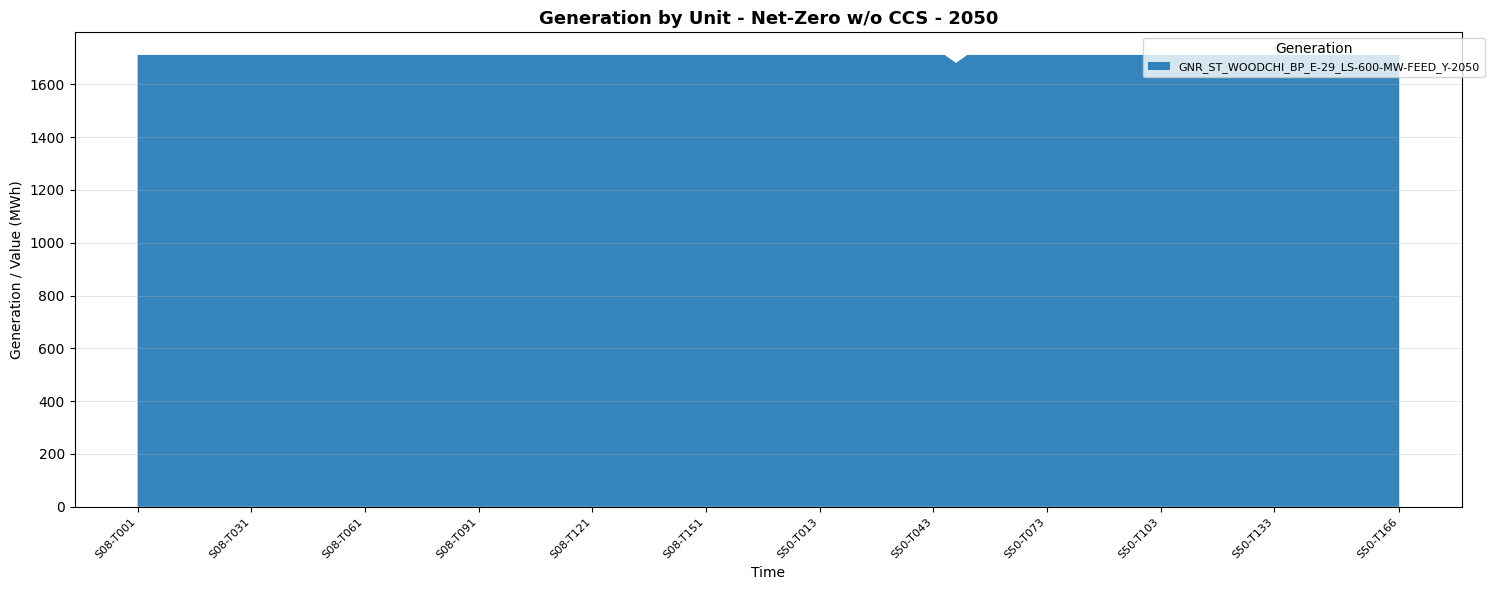

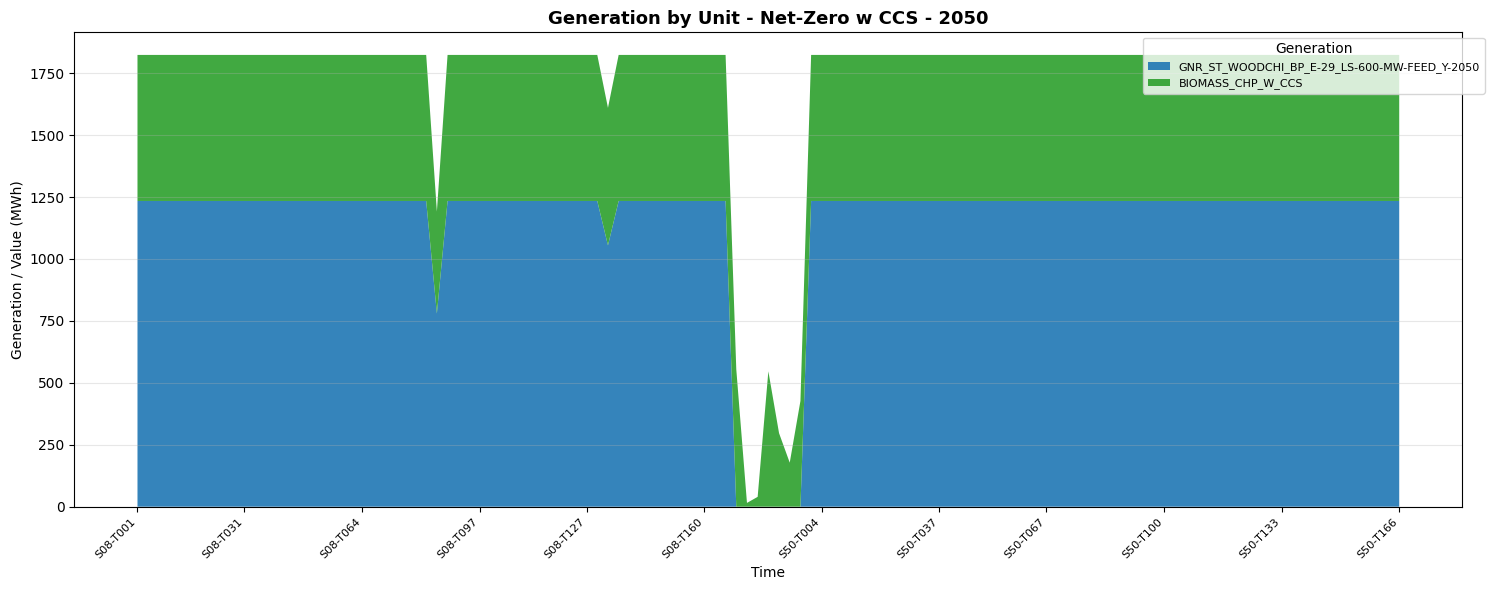

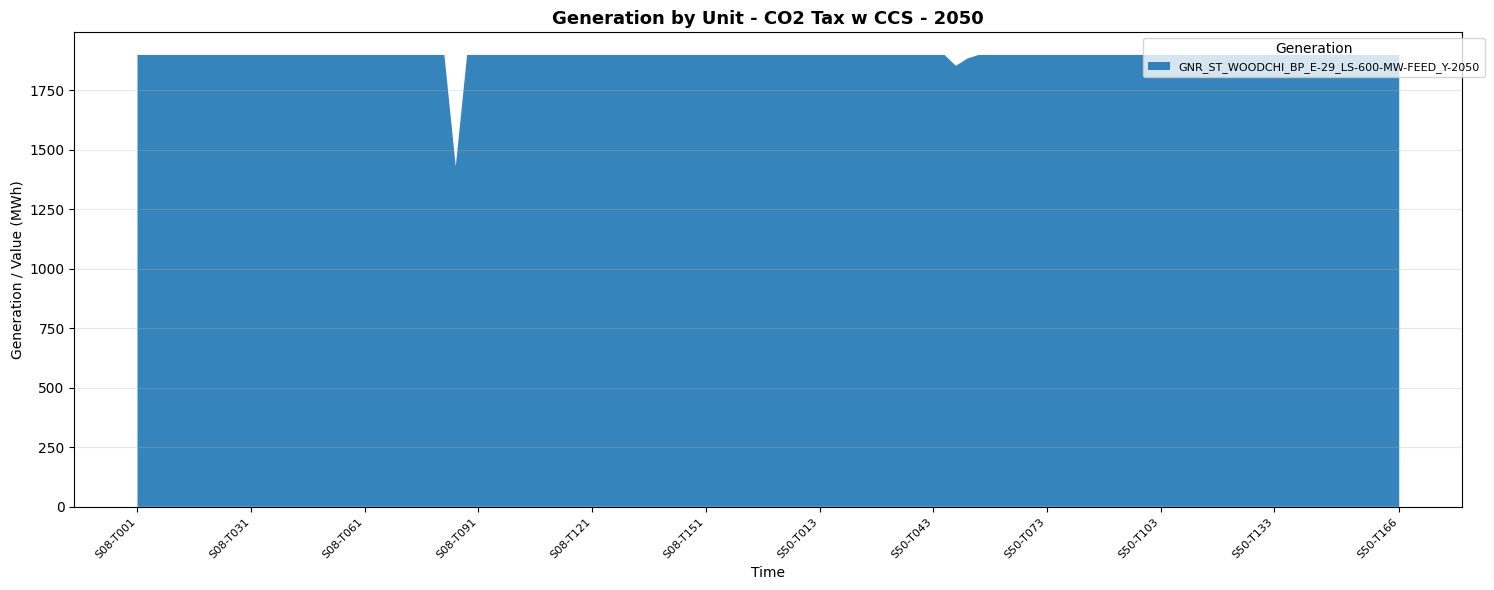

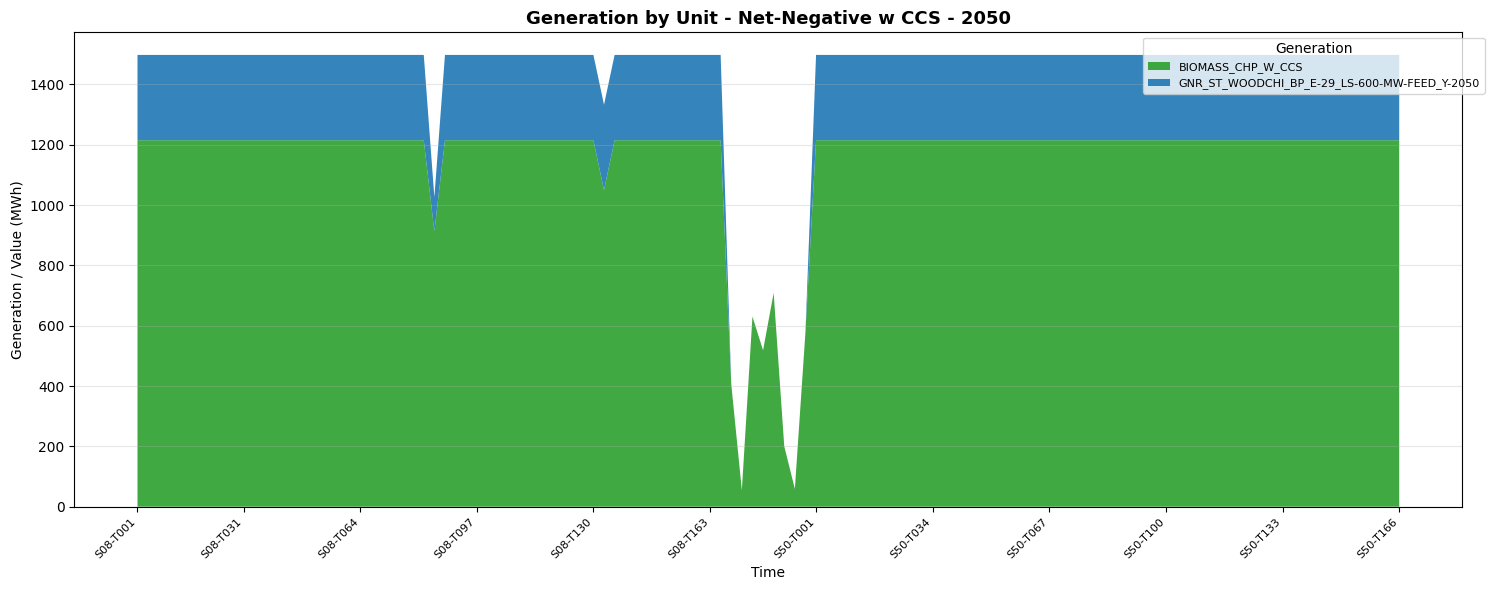

In [24]:
scenarios = [
    "Net-Zero w/o CCS",
    "Net-Zero w CCS",
    "CO2 Tax w CCS",
    "Net-Negative w CCS",
]


figures = plot_generation_stacked_by_technology_per_scenario(
    generation_df=F_CONS_YCRAT_bio,
    scenarios=scenarios,
    year=2050,
)

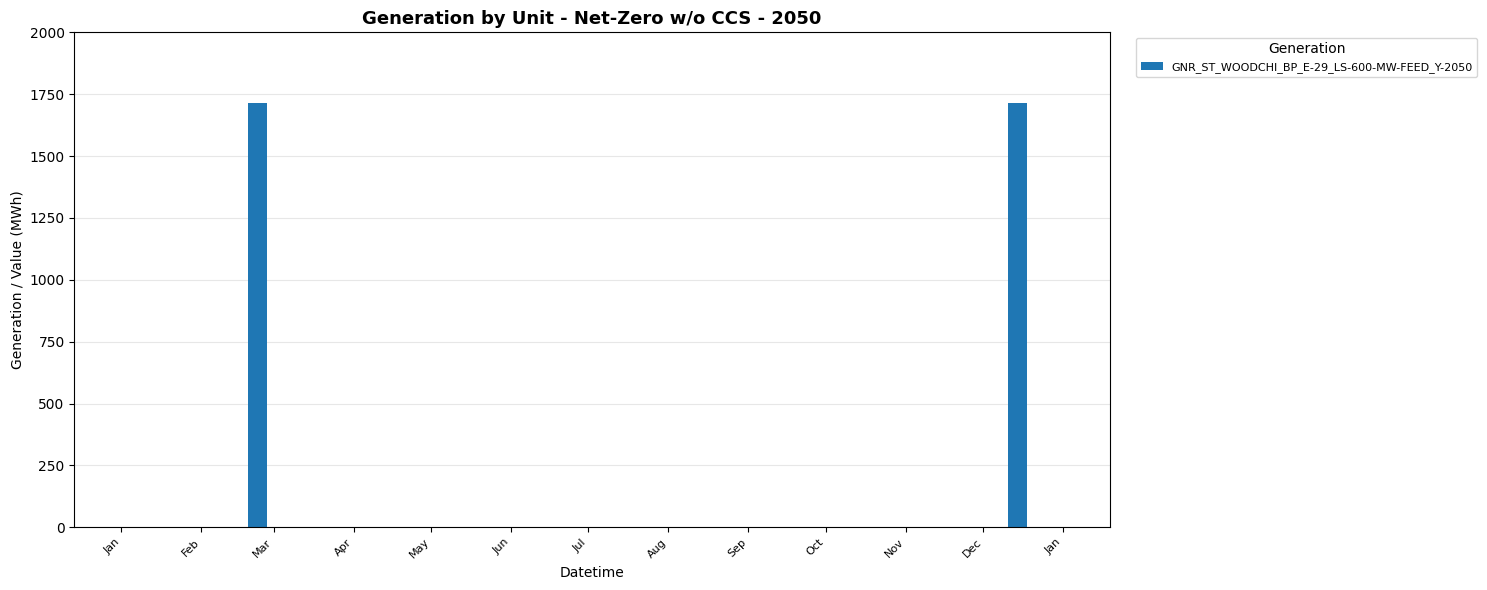

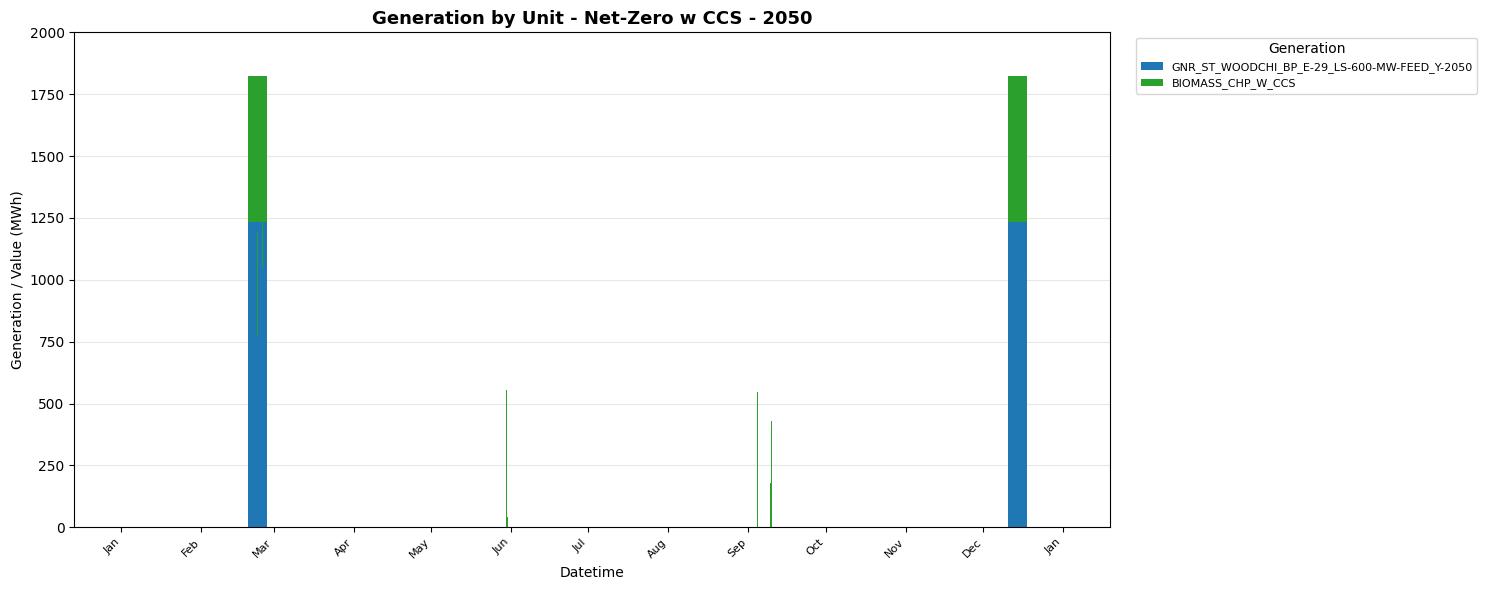

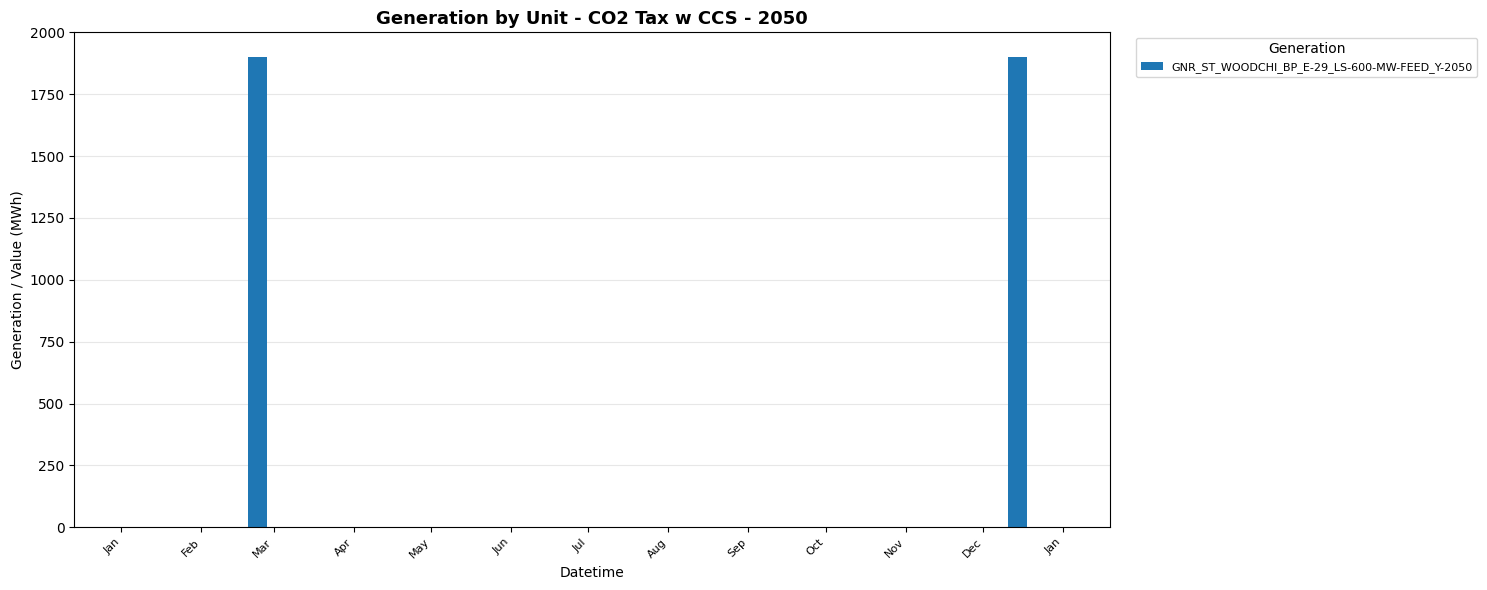

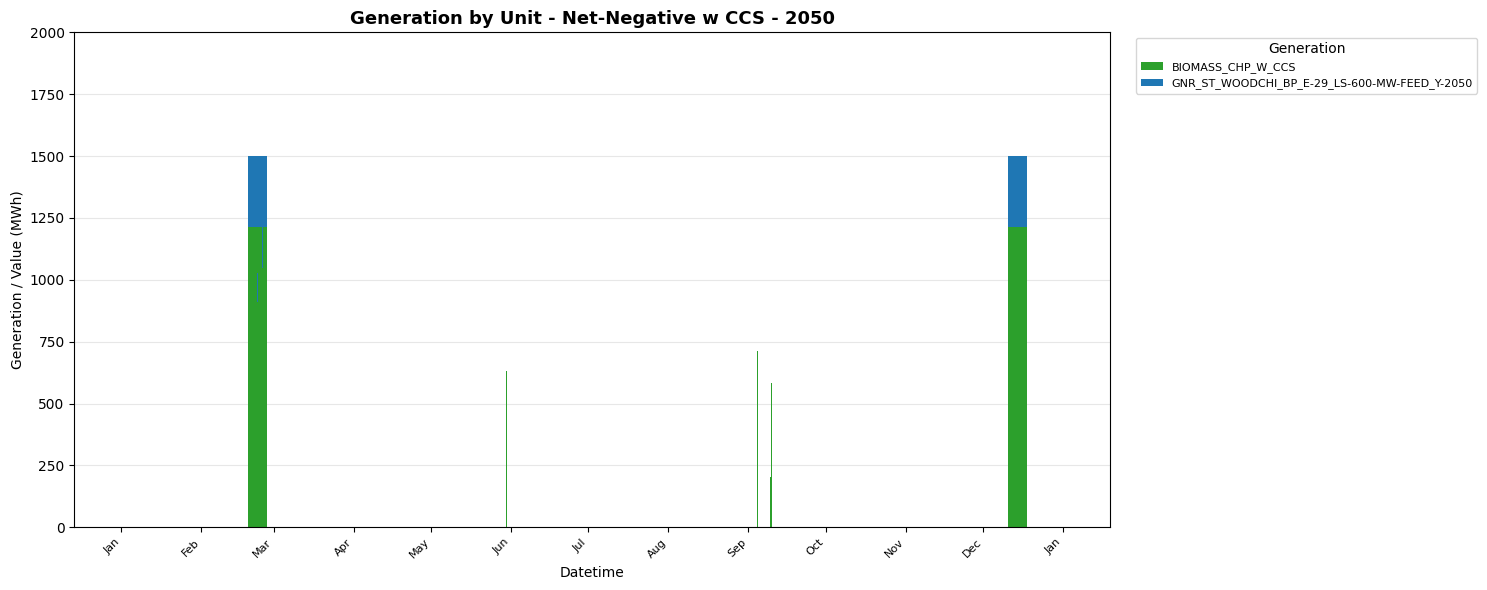

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def create_balmorel_datetime_df(
    year: int,
    n_seasons: int = 52,
    season_col: str = "Season",
    time_col: str = "Time",
):
    """
    Create a Balmorel-like SSS/TTT datetime mapping.

    Assumes:
        Season values look like S01, S02, ...
        Time values look like T001, T002, ...
    """

    datetime_index = pd.date_range(
        start=f"{year}-01-01 00:00:00",
        end=f"{year}-12-31 23:00:00",
        freq="h",
    )

    time_df = pd.DataFrame({"DATETIME": datetime_index})

    time_df["Year"] = time_df["DATETIME"].dt.year
    time_df["Month"] = time_df["DATETIME"].dt.month
    time_df["Day"] = time_df["DATETIME"].dt.day
    time_df["Hour"] = time_df["DATETIME"].dt.hour + 1
    time_df["HourOfYear"] = np.arange(1, len(time_df) + 1)

    time_df["Season_num"] = (
        ((time_df["HourOfYear"] - 1) * n_seasons // len(time_df)) + 1
    )

    time_df["Time_num"] = (
        time_df
        .groupby("Season_num")
        .cumcount()
        + 1
    )

    time_df[season_col] = "S" + time_df["Season_num"].astype(str).str.zfill(2)
    time_df[time_col] = "T" + time_df["Time_num"].astype(str).str.zfill(3)

    return time_df[
        [
            "DATETIME",
            "Year",
            "Month",
            "Day",
            "Hour",
            "HourOfYear",
            "Season_num",
            "Time_num",
            season_col,
            time_col,
        ]
    ]


def plot_generation_stacked_by_technology_per_scenario(
    generation_df: pd.DataFrame,
    scenarios: list = None,
    year: int = None,
    country: str = None,
    region: str = None,
    area: str = None,
    min_value: float = 0.0,
    n_seasons: int = 52,
):
    """
    Plot generation/value over time as stacked area plots, one plot per scenario.
    The stack is grouped by Generation.

    The function creates a full Balmorel SSS/TTT datetime mapping and merges it
    into the results, so the x-axis covers the whole year even when some
    Season-Time combinations have no data.

    If the generation name starts with 'BIO', it is plotted in green.
    Otherwise, it is plotted in blue.
    """

    if year is None:
        raise ValueError("You must provide year to create the full Balmorel datetime axis.")

    df = generation_df.copy()

    df["Scenario_clean"] = df["Scenario"].astype(str).str.strip()
    df["Scenario_key"] = df["Scenario_clean"].str.lower()
    df["Generation"] = df["Generation"].astype(str).str.strip()
    df["Year"] = df["Year"].astype(int)

    df["Season"] = df["Season"].astype(str).str.strip()
    df["Time"] = df["Time"].astype(str).str.strip()

    # Optional filters
    df = df[df["Year"] == int(year)]

    if country is not None:
        df = df[df["Country"].astype(str).str.upper() == country.upper()]

    if region is not None:
        df = df[df["Region"].astype(str).str.upper() == region.upper()]

    if area is not None:
        df = df[df["Area"].astype(str).str.upper() == area.upper()]

    if scenarios is None:
        scenario_list = sorted(df["Scenario_clean"].unique())
    else:
        scenario_keys = [str(s).strip().lower() for s in scenarios]
        df = df[df["Scenario_key"].isin(scenario_keys)]

        scenario_order = {
            str(s).strip().lower(): str(s).strip()
            for s in scenarios
        }

        df["Scenario_clean"] = df["Scenario_key"].map(scenario_order)
        scenario_list = [str(s).strip() for s in scenarios]

    if df.empty:
        raise ValueError("No data available after filtering.")

    # Create full Balmorel time mapping
    time_df = create_balmorel_datetime_df(
        year=year,
        n_seasons=n_seasons,
        season_col="Season",
        time_col="Time",
    )

    full_datetime_axis = time_df[["DATETIME", "Season", "Time"]].copy()

    # Merge DATETIME into generation dataframe
    df = df.merge(
        time_df[["DATETIME", "Season", "Time"]],
        on=["Season", "Time"],
        how="left",
    )

    # Remove rows that did not match the Balmorel time structure
    df = df.dropna(subset=["DATETIME"])

    # Remove zero or negative values only for stacked values
    df = df[df["Value"] > 0]

    if df.empty:
        raise ValueError("No positive generation values available after filtering.")

    figures = {}

    for scenario in scenario_list:
        scenario_df = df[df["Scenario_clean"] == scenario].copy()

        if scenario_df.empty:
            continue

        # Aggregate by datetime and generation unit
        plot_df = (
            scenario_df
            .groupby(["DATETIME", "Generation"], as_index=False)["Value"]
            .sum()
            .sort_values("DATETIME")
        )

        pivot_df = (
            plot_df
            .pivot_table(
                index="DATETIME",
                columns="Generation",
                values="Value",
                aggfunc="sum",
                fill_value=0,
            )
            .reset_index()
        )

        # Fill the whole year using the full Balmorel datetime axis
        pivot_df = (
            full_datetime_axis[["DATETIME"]]
            .merge(
                pivot_df,
                on="DATETIME",
                how="left",
            )
            .sort_values("DATETIME")
            .fillna(0)
        )

        value_df = pivot_df.drop(columns=["DATETIME"], errors="ignore")

        if value_df.empty:
            continue

        # Group small generation units into Other
        generation_totals = value_df.sum(axis=0)
        small_generators = generation_totals[generation_totals < min_value].index

        if len(small_generators) > 0:
            value_df["Other"] = value_df[small_generators].sum(axis=1)
            value_df = value_df.drop(columns=small_generators)

        # Remove columns that are entirely zero after grouping
        value_df = value_df.loc[:, value_df.sum(axis=0) > 0]

        if value_df.empty:
            continue

        # Sort generation units by total value
        value_df = value_df[
            value_df.sum(axis=0).sort_values(ascending=False).index
        ]

        # BIO* = green, everything else = blue
        colors = [
            "tab:green" if str(generator).strip().upper().startswith("BIO")
            else "tab:blue"
            for generator in value_df.columns
        ]

        x = pivot_df["DATETIME"]

        fig, ax = plt.subplots(figsize=(15, 6))

        # --- REPLACED STACKPLOT WITH STEPPED FILL_BETWEEN FOR SOLID COLORS ---
        y_stack = value_df.T.values
        y_cumulative = np.zeros(len(x))

        for i, col in enumerate(value_df.columns):
            y_next = y_cumulative + y_stack[i]
            ax.fill_between(
                x,
                y_cumulative,
                y_next,
                label=col,
                color=colors[i],
                step="mid",  # Ensures sharp, blocky, solid bars instead of thin triangles
                edgecolor="none",
                alpha=1.0,
                zorder=2,
                antialiased=False,
            )
            y_cumulative = y_next
        # --------------------------------------------------------------------

        title = f"Generation by Unit - {scenario} - {year}"
        if country is not None:
            title += f" - {country}"
        if region is not None:
            title += f" - {region}"
        if area is not None:
            title += f" - {area}"

        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_ylabel("Generation / Value (MWh)")
        ax.set_xlabel("Datetime")
        
        # --- NEW LINE ADDED TO FIX Y-AXIS LIMITS ---
        ax.set_ylim(0, 2000)
        # -------------------------------------------
        
        ax.grid(True, axis="y", alpha=0.3, zorder=0)

        # Monthly x-axis labels
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

        plt.setp(
            ax.get_xticklabels(),
            rotation=45,
            ha="right",
            fontsize=8,
        )

        ax.legend(
            title="Generation",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            fontsize=8,
        )

        plt.tight_layout()

        figures[scenario] = (fig, ax)

    return figures

# Example usage (ensure your DataFrame 'F_CONS_YCRAT_bio' is defined)
scenarios = [
    "Net-Zero w/o CCS",
    "Net-Zero w CCS",
    "CO2 Tax w CCS",
    "Net-Negative w CCS",
]

figures = plot_generation_stacked_by_technology_per_scenario(
    generation_df=F_CONS_YCRAT_bio,
    scenarios=scenarios,
    year=2050,
    country=None,
    region=None,
    area=None,
    min_value=0.0,
    n_seasons=52,
)

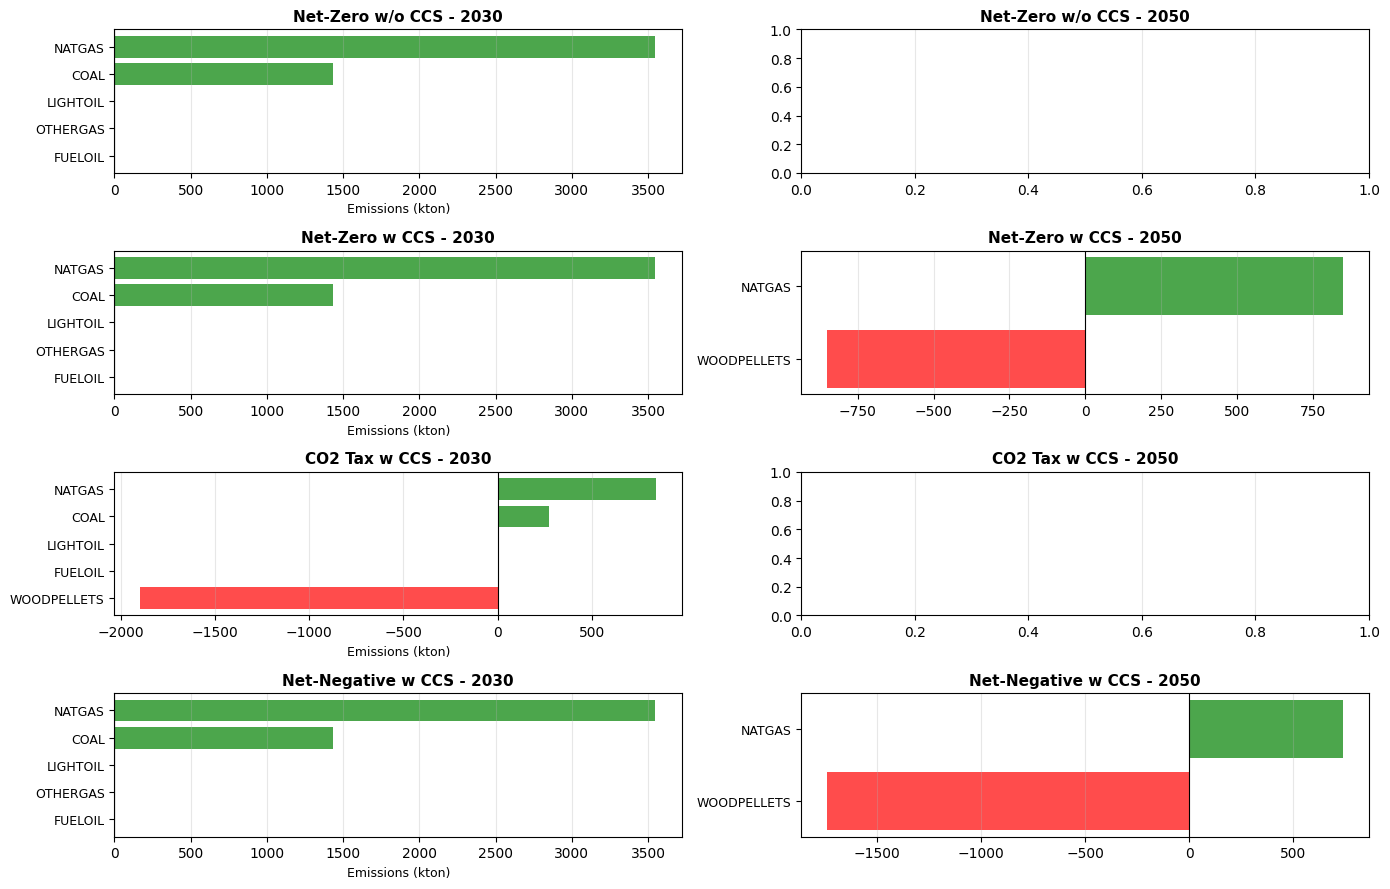

In [35]:
import matplotlib.pyplot as plt
import numpy as np


def plot_emissions_grid_by_year_and_scenario(
    emissions_df: pd.DataFrame, years: list = None, scenarios: list = None
):
    """Plot emissions in a 2x2 grid (years as columns, scenarios as rows), grouped by fuel.

    Args:
        emissions_df (pd.DataFrame): Emissions results dataframe.
        years (list, optional): Years to plot. Defaults to all available.
        scenarios (list, optional): Scenarios to plot. Defaults to all available.

    Returns:
        tuple[plt.Figure, np.ndarray]: The figure and axes array.
    """
    # Get available years and scenarios
    if years is None:
        years = sorted(emissions_df["Y"].unique())
    else:
        years = [str(y) for y in years]  # Convert to strings to match data

    if scenarios is None:
        scenarios = sorted(emissions_df["Scenario"].unique())

    # Create 2x2 grid (rows=scenarios, columns=years)
    fig, axes = plt.subplots(len(scenarios), len(years), figsize=(14, 9))
    if len(scenarios) == 1 and len(years) == 1:
        axes = np.array([[axes]])
    elif len(scenarios) == 1:
        axes = axes.reshape(1, -1)
    elif len(years) == 1:
        axes = axes.reshape(-1, 1)

    # Plot each combination
    for i, scenario in enumerate(scenarios):
        for j, year in enumerate(years):
            ax = axes[i, j]

            # Filter data for this scenario and year
            filtered = emissions_df[
                (emissions_df["Scenario"] == scenario) & (emissions_df["Y"] == year)
            ]

            if not filtered.empty:
                # Group by fuel type and sum emissions
                fuel_emissions = filtered.groupby("FFF")["Value"].sum().sort_values()

                # Plot as horizontal bar chart for better readability
                colors = ["red" if v < 0 else "green" for v in fuel_emissions.values]
                ax.barh(
                    range(len(fuel_emissions)),
                    fuel_emissions.values,
                    color=colors,
                    alpha=0.7,
                )
                ax.set_yticks(range(len(fuel_emissions)))
                ax.set_yticklabels(fuel_emissions.index, fontsize=9)
                ax.axvline(0, color="black", linewidth=0.8)

            ax.set_title(f"{scenario} - {year}", fontsize=11, fontweight="bold")
            ax.set_xlabel("Emissions (kton)" if j == 0 else "", fontsize=9)
            ax.grid(True, axis="x", alpha=0.3)

    plt.tight_layout()
    return fig, axes


# Plot 2x2 grid: rows=scenarios, columns=years
scenarios = [
    "Net-Zero w/o CCS",
    "Net-Zero w CCS",
    "CO2 Tax w CCS",
    "Net-Negative w CCS",
]
years = [2030, 2050]
fig, axes = plot_emissions_grid_by_year_and_scenario(
    EMI_YCRAG, years=years, scenarios=scenarios
)

ValueError: 'center top' is not a valid value for loc; supported values are 'best', 'upper right', 'upper left', 'lower left', 'lower right', 'right', 'center left', 'center right', 'lower center', 'upper center', 'center'

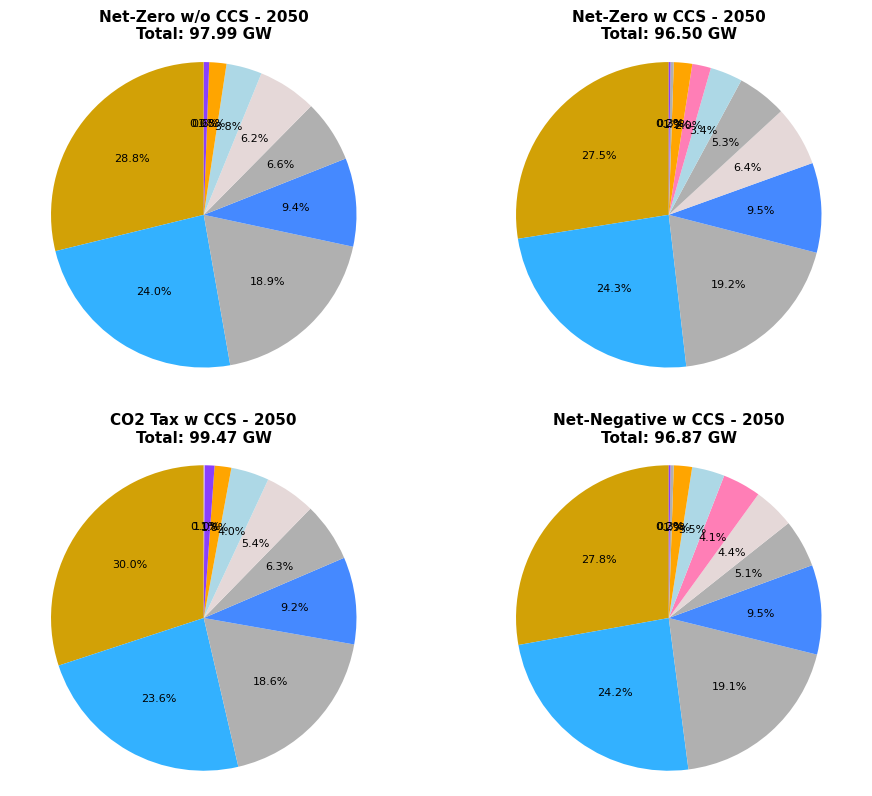

In [28]:
import pandas as pd
def plot_capacity_pie_by_scenario(
    capacity_df: pd.DataFrame,
    year: int = None,
    scenarios: list = None,
    min_capacity: float = 0.0,
):
    """
    Plot installed capacity mix as pie charts:
    one pie chart per scenario.

    Technologies whose name contains 'storage' are removed.

    Args:
        capacity_df (pd.DataFrame): Installed capacity results dataframe.
        year (int, optional): Year to plot. If None, uses all years.
        scenarios (list, optional): Scenarios to plot. Defaults to all available.
        min_capacity (float, optional): Minimum total technology capacity to show.
            Technologies below this total are grouped as 'Other'.

    Returns:
        tuple[plt.Figure, np.ndarray]: The figure and axes.
    """

    generation_tech_color = {
        "HYDRO-RESERVOIRS": "#33b1ff",
        "HYDRO-RUN-OF-RIVER": "#4589ff",
        "HYDRO": "#33b1ff",
        "WIND-ONSHORE": "#006460",
        "BOILERS": "#8B008B",
        "ELECT-TO-HEAT": "#FFA500",
        "INTERSEASONAL-HEAT-STORAGE": "#FFD700",
        "CHP-BACK-PRESSURE": "#E5D8D8",
        "SMR-CCS": "#00BFFF",
        "SMR": "#d1b9b9",
        "INTRASEASONAL-HEAT-STORAGE": "#00FFFF",
        "CONDENSING": "#8a3ffc",
        "SOLAR-HEATING": "#FF69B4",
        "CHP-EXTRACTION": "#ff7eb6",
        "SOLAR-PV": "#d2a106",
        "WIND-OFFSHORE": "#08bdba",
        "INTRASEASONAL-ELECT-STORAGE": "#ba4e00",
        "ELECTROLYZER": "#ADD8E6",
        "H2-STORAGE": "#FFC0CB",
        "FUELCELL": "#d4bbff",
        "CHP": "#E5D8D8",
    }

    df = capacity_df.copy()

    # Remove all technologies containing "storage"
    df = df[
        ~df["Technology"]
        .astype(str)
        .str.lower()
        .str.contains("storage", na=False)
    ]

    df["Scenario_clean"] = df["Scenario"].astype(str).str.strip()
    df["Scenario_key"] = df["Scenario_clean"].str.lower()
    df["Year"] = df["Year"].astype(int)

    if year is not None:
        year = int(year)
        df = df[df["Year"] == year]

    if scenarios is None:
        scenarios = sorted(df["Scenario_clean"].unique())
    else:
        scenario_keys = [str(s).strip().lower() for s in scenarios]
        df = df[df["Scenario_key"].isin(scenario_keys)]

        scenario_order = {
            str(s).strip().lower(): str(s).strip()
            for s in scenarios
        }

        df["Scenario_clean"] = df["Scenario_key"].map(scenario_order)

    plot_df = (
        df.groupby(["Scenario_clean", "Technology"])["Value"]
        .sum()
        .reset_index()
    )

    # Remove zero or negative capacities
    plot_df = plot_df[plot_df["Value"] > 0]

    if plot_df.empty:
        raise ValueError("No positive capacity values available after filtering.")

    # Number of pie charts
    n_scenarios = len(scenarios) if scenarios is not None else plot_df["Scenario_clean"].nunique()

    n_cols = min(2, n_scenarios)
    n_rows = int(np.ceil(n_scenarios / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5.5 * n_cols, 4.8 * n_rows),
    )

    axes = np.array(axes).reshape(-1)

    if scenarios is None:
        scenario_list = sorted(plot_df["Scenario_clean"].unique())
    else:
        scenario_list = [str(s).strip() for s in scenarios]

    all_legend_handles = {}
    fallback_color = "#B0B0B0"

    for idx, scenario in enumerate(scenario_list):
        ax = axes[idx]

        scenario_df = plot_df[plot_df["Scenario_clean"] == scenario]

        if scenario_df.empty:
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                fontsize=10,
            )
            ax.set_title(scenario, fontsize=11, fontweight="bold")
            ax.axis("off")
            continue

        technology_capacity = (
            scenario_df.groupby("Technology")["Value"]
            .sum()
            .sort_values(ascending=False)
        )

        # Group small technologies into "Other"
        small_techs = technology_capacity[technology_capacity < min_capacity]

        if not small_techs.empty:
            large_techs = technology_capacity[technology_capacity >= min_capacity]
            technology_capacity = pd.concat(
                [
                    large_techs,
                    pd.Series({"Other": small_techs.sum()}),
                ]
            )

        colors = []
        for technology in technology_capacity.index:
            technology_key = str(technology).strip().upper()
            colors.append(generation_tech_color.get(technology_key, fallback_color))

        wedges, texts, autotexts = ax.pie(
            technology_capacity.values,
            labels=None,
            autopct="%1.1f%%",
            startangle=90,
            colors=colors,
            textprops={"fontsize": 8},
        )

        for tech, wedge in zip(technology_capacity.index, wedges):
            all_legend_handles[tech] = wedge

        total_capacity = technology_capacity.sum()

        title = f"{scenario}"
        if year is not None:
            title += f" - {year}"
        title += f"\nTotal: {total_capacity:.2f} GW"

        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.axis("equal")

    # Turn off unused subplots
    for idx in range(len(scenario_list), len(axes)):
        axes[idx].axis("off")

    fig.legend(
        all_legend_handles.values(),
        all_legend_handles.keys(),
        title="Technology",
        bbox_to_anchor=(1.02, 0.5),
        loc="center top",
        fontsize=8,
    )

    main_title = "Installed Capacity Mix by Scenario"
    if year is not None:
        main_title += f" - {year}"

    fig.suptitle(main_title, fontsize=14, fontweight="bold", y=1.02)

    plt.tight_layout()

    return fig, axes

scenarios = [
    "Net-Zero w/o CCS",
    "Net-Zero w CCS",
    "CO2 Tax w CCS",
    "Net-Negative w CCS",
]

fig, ax = plot_capacity_pie_by_scenario(
    G_CAP_YCRAF,
    year=2050,
    scenarios=scenarios,
    min_capacity=0.0,
)

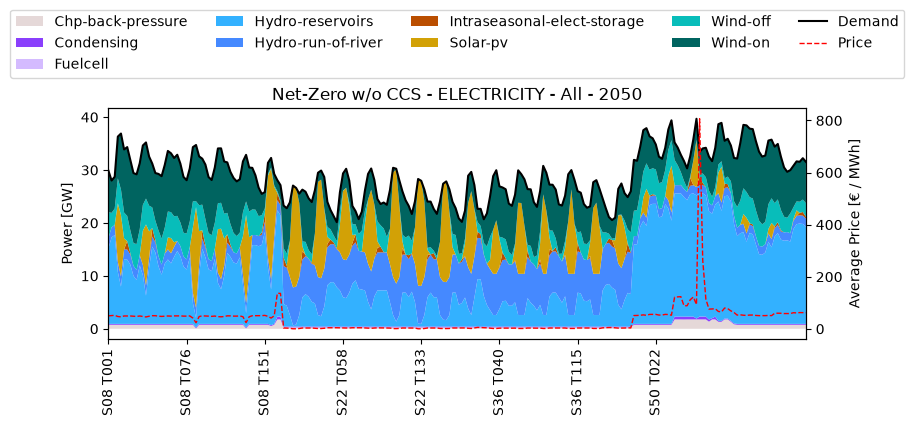

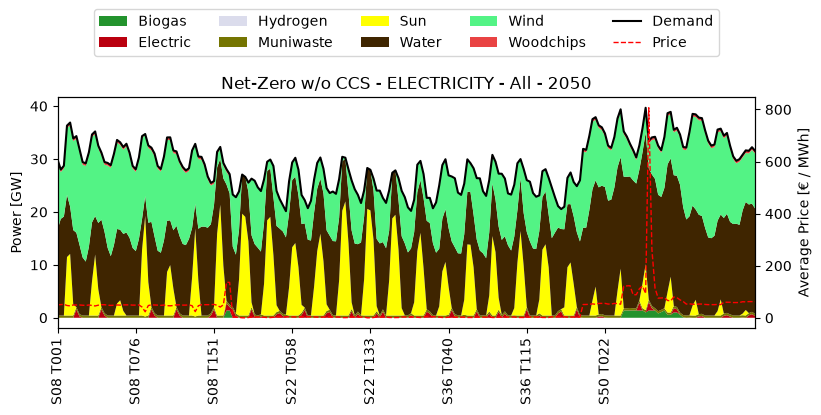

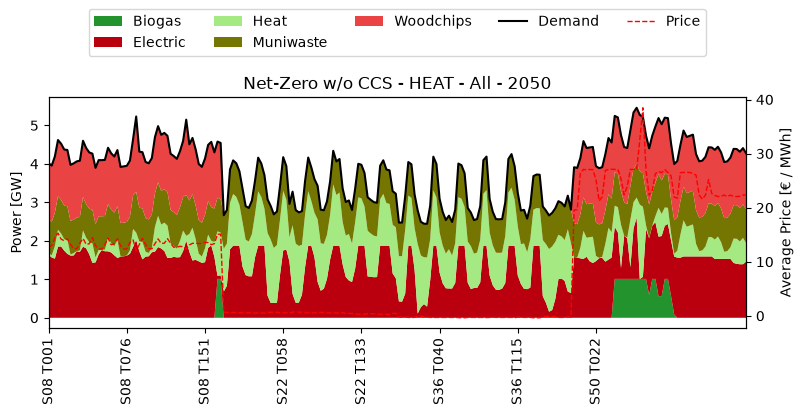

In [ ]:
fig, ax = res.plot_profile(scenario='Net-Zero w/o CCS', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='Net-Zero w/o CCS', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='Net-Zero w/o CCS', year=2050, commodity='Heat', columns='Fuel')

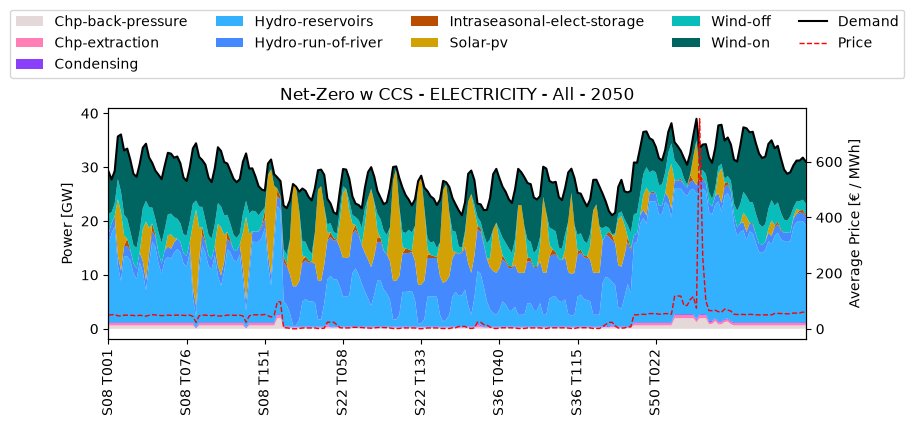

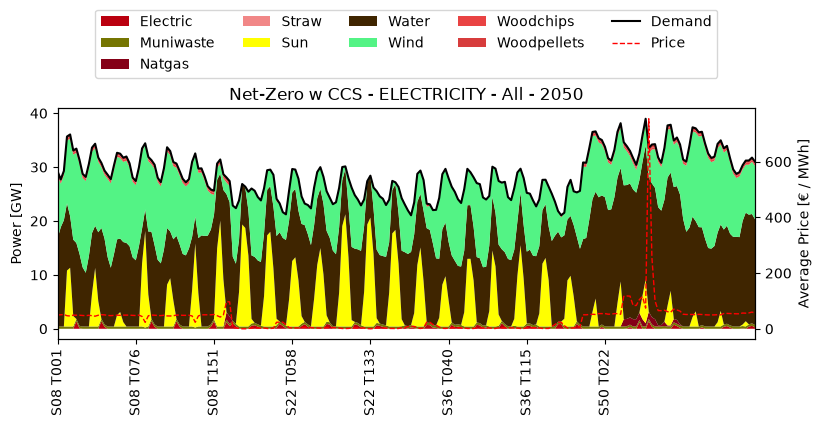

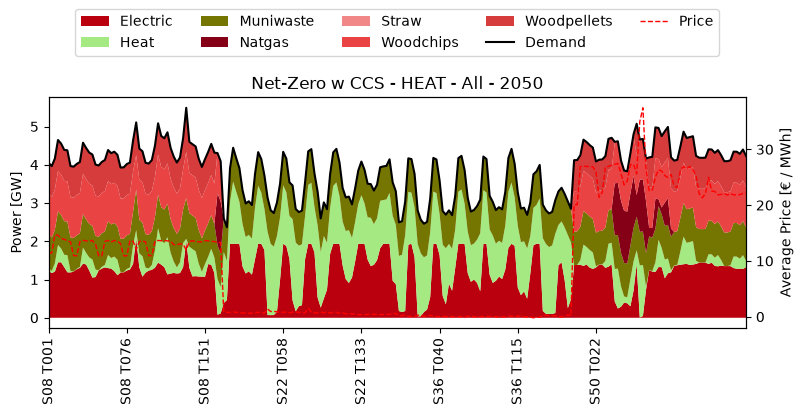

In [ ]:
fig, ax = res.plot_profile(scenario='Net-Zero w CCS', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='Net-Zero w CCS', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='Net-Zero w CCS', year=2050, commodity='Heat', columns='Fuel')

No defined colour for WOODWASTE
No defined colour for WOODWASTE


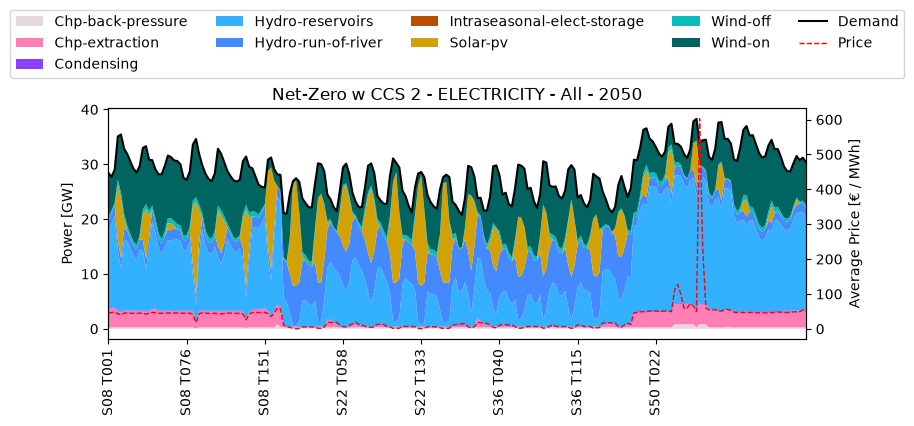

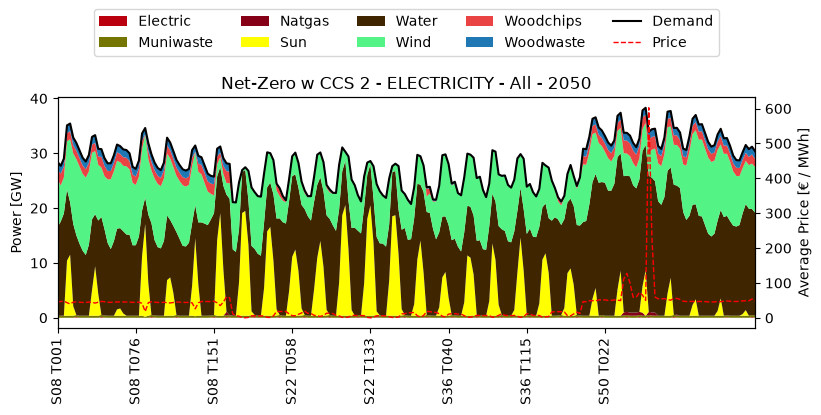

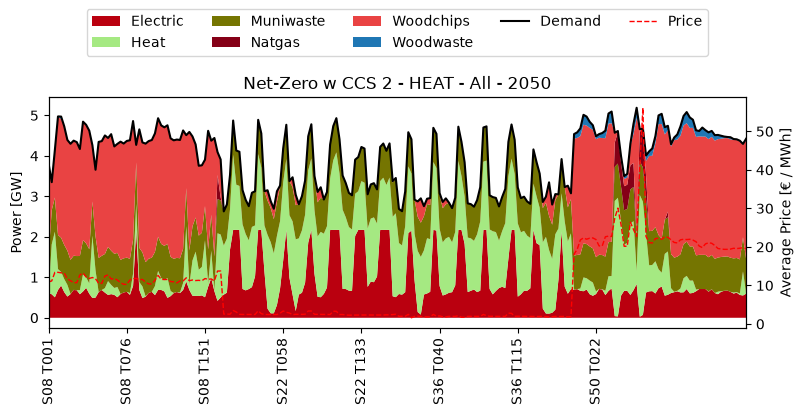

In [ ]:
fig, ax = res.plot_profile(scenario='Net-Zero w CCS 2', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='Net-Zero w CCS 2', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='Net-Zero w CCS 2', year=2050, commodity='Heat', columns='Fuel')

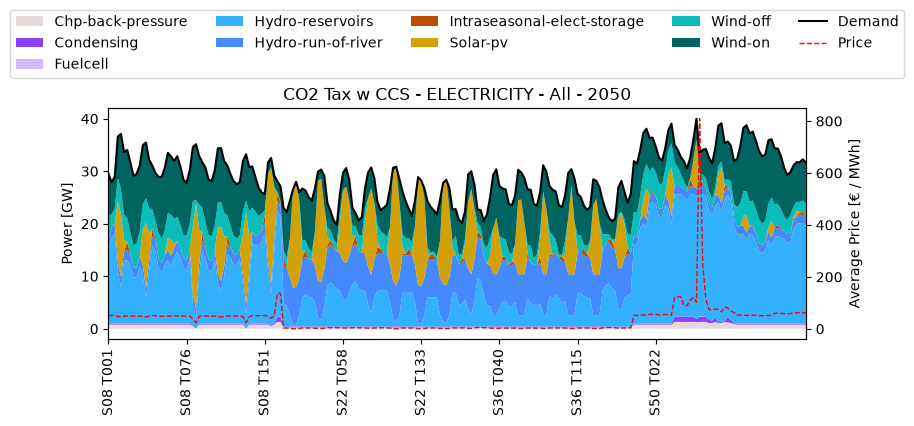

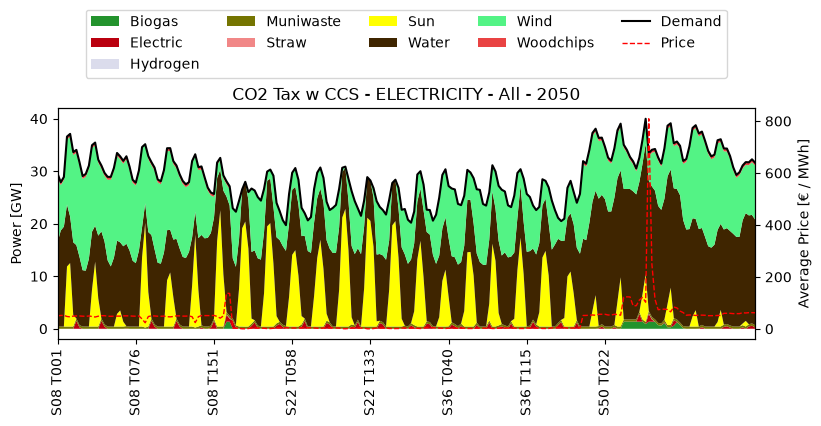

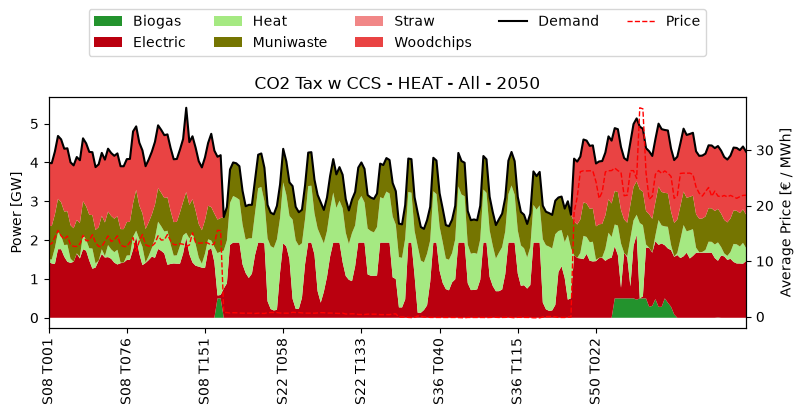

In [ ]:
fig, ax = res.plot_profile(scenario='CO2 Tax w CCS', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='CO2 Tax w CCS', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='CO2 Tax w CCS', year=2050, commodity='Heat', columns='Fuel')

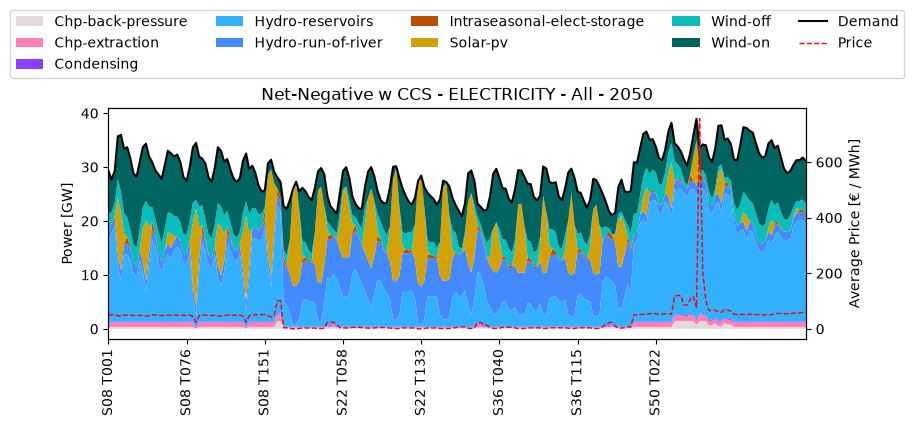

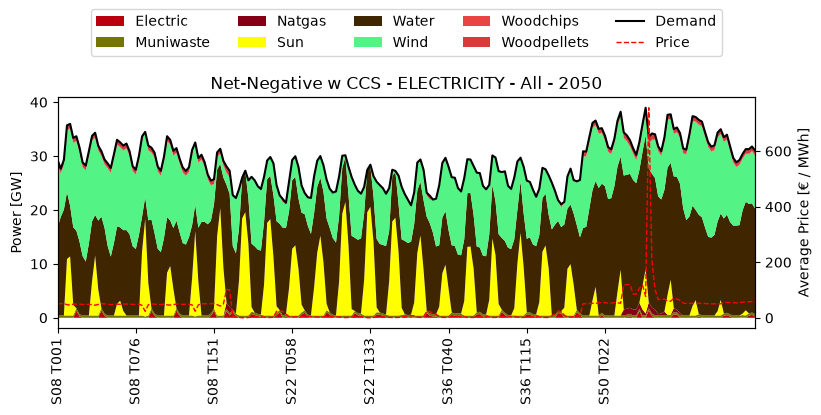

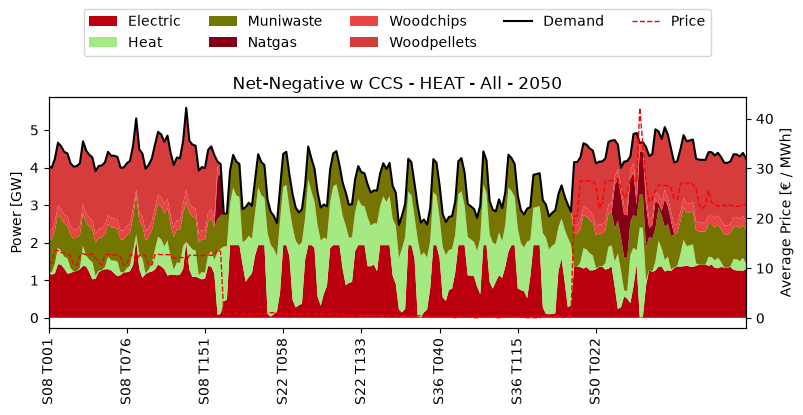

In [ ]:
fig, ax = res.plot_profile(scenario='Net-Negative w CCS', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='Net-Negative w CCS', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='Net-Negative w CCS', year=2050, commodity='Heat', columns='Fuel')